# EDA dữ liệu raw — Online Retail

Notebook này **chỉ đọc** `data/raw/data.csv` để kiểm tra chất lượng và phân bố dữ liệu nguồn. Ngày giao dịch được giữ nguyên 2010–2011. Chạy các ô từ trên xuống dưới; không cần chạy ETL trước.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")
root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
raw_path = root / "data/raw/data.csv"
raw = pd.read_csv(raw_path, encoding="ISO-8859-1", low_memory=False)
raw["InvoiceDateParsed"] = pd.to_datetime(raw["InvoiceDate"], format="%m/%d/%Y %H:%M", errors="coerce")
print(f"Rows: {len(raw):,} | Columns: {len(raw.columns) - 1}")
print(f"Dates: {raw.InvoiceDateParsed.min()} to {raw.InvoiceDateParsed.max()}")
raw.head()

Rows: 541,909 | Columns: 8
Dates: 2010-12-01 08:26:00 to 2011-12-09 12:50:00


  InvoiceNo StockCode  ...         Country   InvoiceDateParsed
0    536365    85123A  ...  United Kingdom 2010-12-01 08:26:00
1    536365     71053  ...  United Kingdom 2010-12-01 08:26:00
2    536365    84406B  ...  United Kingdom 2010-12-01 08:26:00
3    536365    84029G  ...  United Kingdom 2010-12-01 08:26:00
4    536365    84029E  ...  United Kingdom 2010-12-01 08:26:00

[5 rows x 9 columns]

## 1. Thiếu dữ liệu

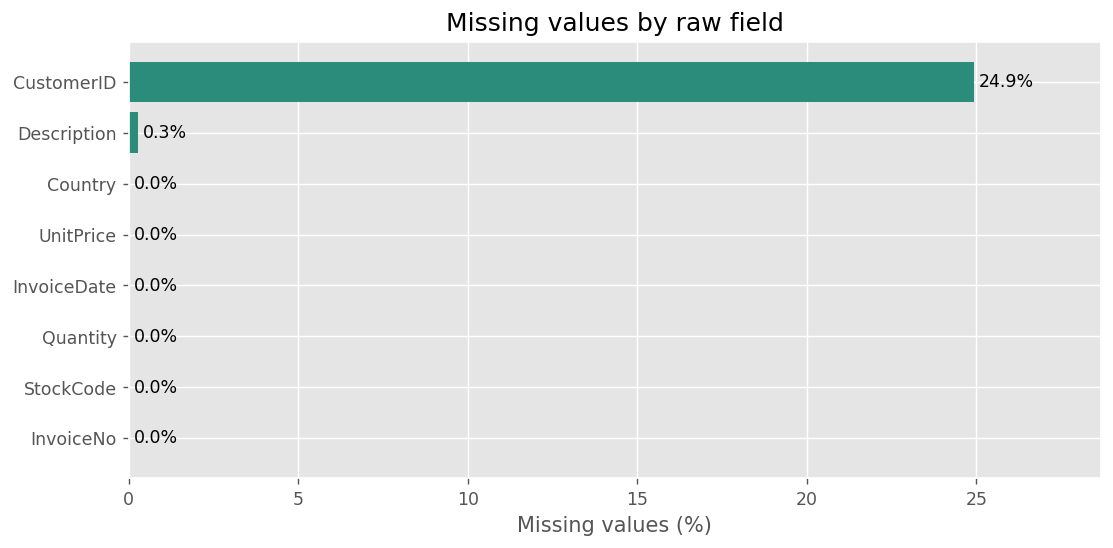

In [2]:
missing_pct = raw.drop(columns="InvoiceDateParsed").isna().mean().mul(100).sort_values()
fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh(missing_pct.index, missing_pct.values, color="#2B8C7C")
ax.bar_label(bars, fmt="%.1f%%", padding=3)
ax.set_xlim(0, max(5, missing_pct.max() * 1.15))
ax.set_xlabel("Missing values (%)")
ax.set_title("Missing values by raw field")
fig.tight_layout()
plt.show()

## 2. Chất lượng giao dịch

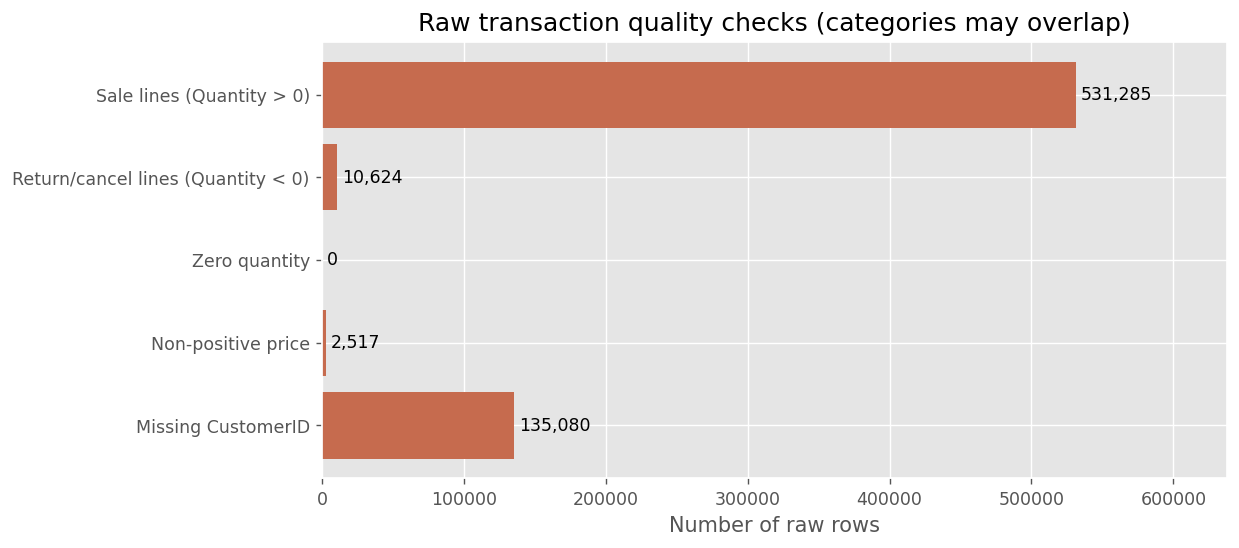

                                      rows  share_pct
Sale lines (Quantity > 0)           531285      98.04
Return/cancel lines (Quantity < 0)   10624       1.96
Zero quantity                            0       0.00
Non-positive price                    2517       0.46
Missing CustomerID                  135080      24.93

In [3]:
quality = pd.Series({
    "Sale lines (Quantity > 0)": raw.Quantity.gt(0).sum(),
    "Return/cancel lines (Quantity < 0)": raw.Quantity.lt(0).sum(),
    "Zero quantity": raw.Quantity.eq(0).sum(),
    "Non-positive price": raw.UnitPrice.le(0).sum(),
    "Missing CustomerID": raw.CustomerID.isna().sum(),
})
fig, ax = plt.subplots(figsize=(10, 4.5))
bars = ax.barh(quality.index[::-1], quality.values[::-1], color="#C66B4E")
ax.bar_label(bars, labels=[f"{v:,}" for v in quality.values[::-1]], padding=3)
ax.set_xlim(0, quality.max() * 1.2)
ax.set_xlabel("Number of raw rows")
ax.set_title("Raw transaction quality checks (categories may overlap)")
fig.tight_layout()
plt.show()
pd.DataFrame({"rows": quality, "share_pct": quality / len(raw) * 100}).round(2)

## 3. Số dòng giao dịch theo tháng gốc

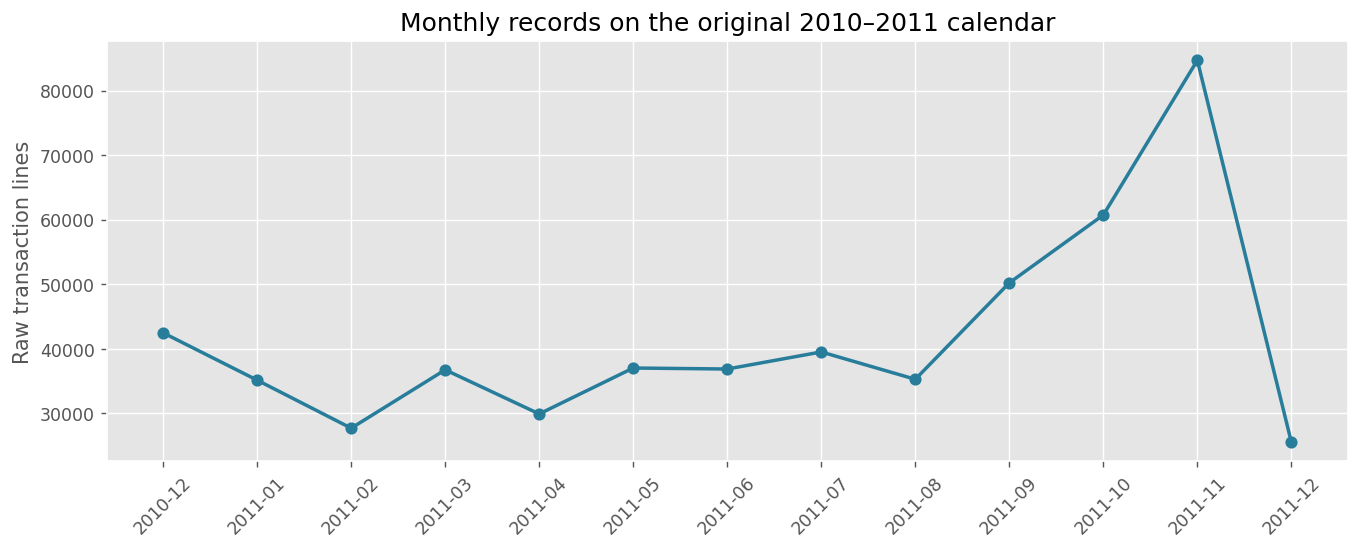

In [4]:
monthly_rows = (raw.dropna(subset=["InvoiceDateParsed"])
                .groupby(raw.InvoiceDateParsed.dt.to_period("M"))
                .size())
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(monthly_rows.index.astype(str), monthly_rows.values, marker="o", linewidth=2, color="#287D9B")
ax.tick_params(axis="x", rotation=45)
ax.set_ylabel("Raw transaction lines")
ax.set_title("Monthly records on the original 2010–2011 calendar")
fig.tight_layout()
plt.show()

## 4. Thị trường trong dữ liệu raw

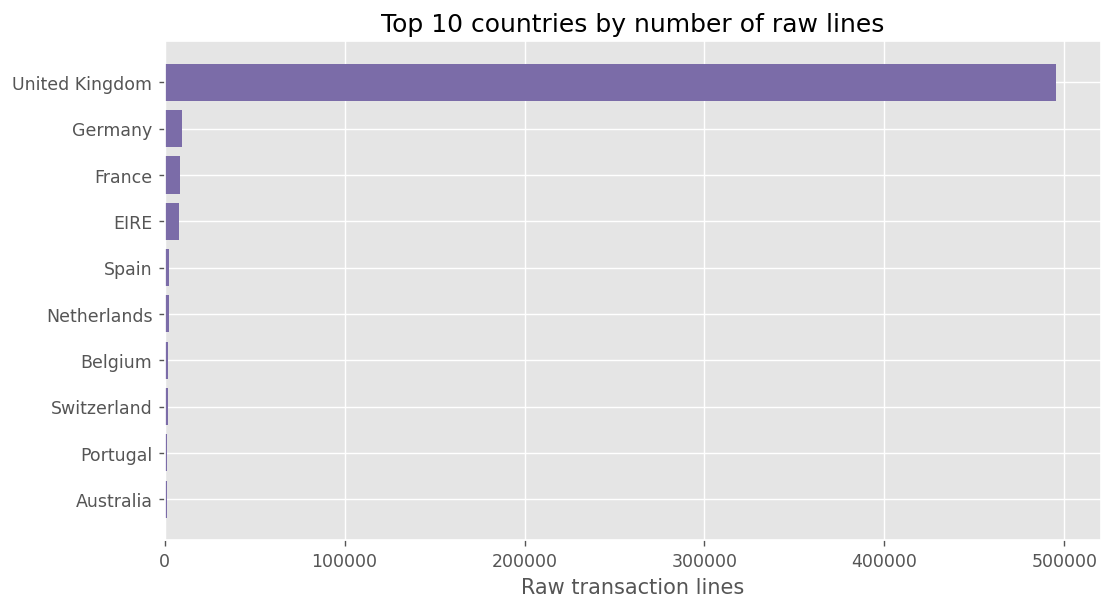

In [5]:
top_countries = raw.Country.value_counts().head(10).sort_values()
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top_countries.index, top_countries.values, color="#7B6CA8")
ax.set_xlabel("Raw transaction lines")
ax.set_title("Top 10 countries by number of raw lines")
fig.tight_layout()
plt.show()

**Ghi chú:** Biểu đồ raw chỉ mô tả nguồn. Các KPI doanh số cần dùng fact sau ETL vì raw gồm cả dòng thiếu CustomerID, giá bằng 0 và giao dịch hoàn.